In [1]:
# Cell 1: Import and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv('../data/creditcard.csv')
print(f"Original dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Original dataset shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [2]:
# Cell 2: Extract time features
# Time is in seconds since first transaction

# Hour of day (0-23)
df['Hour'] = (df['Time'] / 3600) % 24

# Day of transaction (assuming 2 days of data)
df['Day'] = (df['Time'] / 86400).astype(int)

# Is it night time? (10 PM - 6 AM)
df['Is_Night'] = ((df['Hour'] >= 22) | (df['Hour'] <= 6)).astype(int)

print("Time features created:")
print(df[['Time', 'Hour', 'Day', 'Is_Night']].head(10))

Time features created:
   Time      Hour  Day  Is_Night
0   0.0  0.000000    0         1
1   0.0  0.000000    0         1
2   1.0  0.000278    0         1
3   1.0  0.000278    0         1
4   2.0  0.000556    0         1
5   2.0  0.000556    0         1
6   4.0  0.001111    0         1
7   7.0  0.001944    0         1
8   7.0  0.001944    0         1
9   9.0  0.002500    0         1


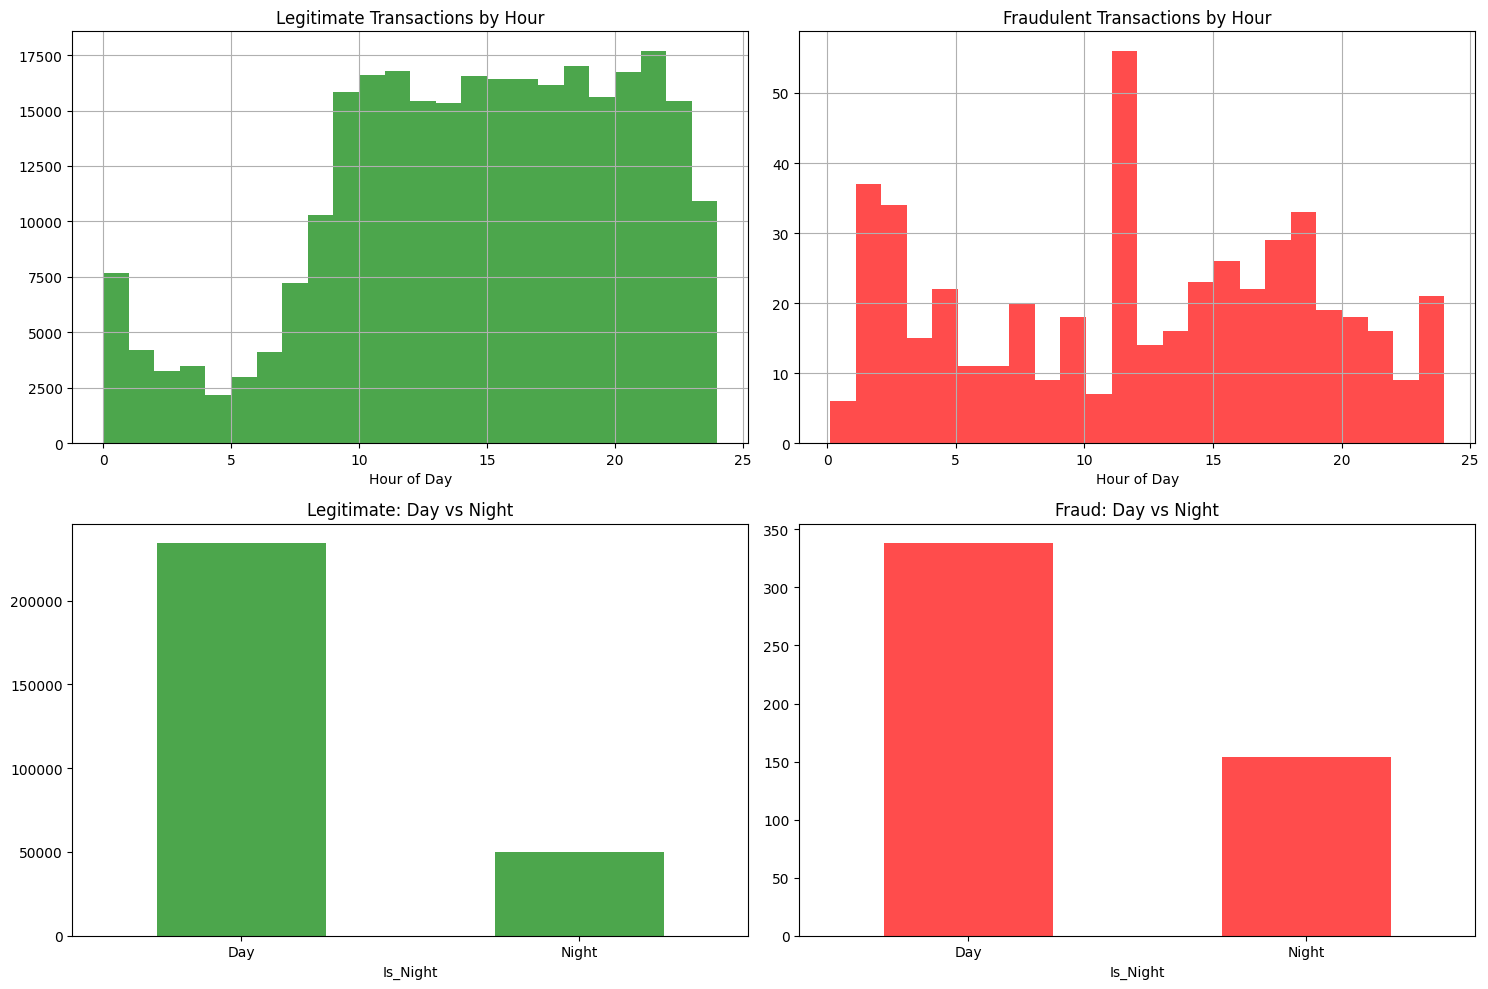


Fraud rate at night: 0.3061%
Fraud rate during day: 0.1441%


In [3]:
# Cell 3: Visualize time patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Hour distribution - Legitimate
df[df['Class']==0]['Hour'].hist(bins=24, ax=axes[0,0], color='green', alpha=0.7)
axes[0,0].set_title('Legitimate Transactions by Hour')
axes[0,0].set_xlabel('Hour of Day')

# Hour distribution - Fraud
df[df['Class']==1]['Hour'].hist(bins=24, ax=axes[0,1], color='red', alpha=0.7)
axes[0,1].set_title('Fraudulent Transactions by Hour')
axes[0,1].set_xlabel('Hour of Day')

# Night vs Day - Legitimate
df[df['Class']==0]['Is_Night'].value_counts().plot(kind='bar', ax=axes[1,0], color='green', alpha=0.7)
axes[1,0].set_title('Legitimate: Day vs Night')
axes[1,0].set_xticklabels(['Day', 'Night'], rotation=0)

# Night vs Day - Fraud
df[df['Class']==1]['Is_Night'].value_counts().plot(kind='bar', ax=axes[1,1], color='red', alpha=0.7)
axes[1,1].set_title('Fraud: Day vs Night')
axes[1,1].set_xticklabels(['Day', 'Night'], rotation=0)

plt.tight_layout()
plt.show()

# Calculate fraud rate by time
fraud_rate_night = df[df['Is_Night']==1]['Class'].mean()
fraud_rate_day = df[df['Is_Night']==0]['Class'].mean()
print(f"\nFraud rate at night: {fraud_rate_night:.4%}")
print(f"Fraud rate during day: {fraud_rate_day:.4%}")

In [4]:
# Cell 4: Create amount features

# Amount categories
def categorize_amount(amount):
    if amount < 10:
        return 'very_small'
    elif amount < 50:
        return 'small'
    elif amount < 100:
        return 'medium'
    elif amount < 500:
        return 'large'
    else:
        return 'very_large'

df['Amount_Category'] = df['Amount'].apply(categorize_amount)

# Log transformation of amount (helps with skewed data)
# Adding 1 to avoid log(0)
df['Amount_Log'] = np.log1p(df['Amount'])

# Is it a round number? (Might indicate automated fraud)
df['Is_Round_Amount'] = (df['Amount'] % 10 == 0).astype(int)

print("Amount features created:")
print(df[['Amount', 'Amount_Category', 'Amount_Log', 'Is_Round_Amount']].head(10))

Amount features created:
   Amount Amount_Category  Amount_Log  Is_Round_Amount
0  149.62           large    5.014760                0
1    2.69      very_small    1.305626                0
2  378.66           large    5.939276                0
3  123.50           large    4.824306                0
4   69.99          medium    4.262539                0
5    3.67      very_small    1.541159                0
6    4.99      very_small    1.790091                0
7   40.80           small    3.732896                0
8   93.20          medium    4.545420                0
9    3.68      very_small    1.543298                0


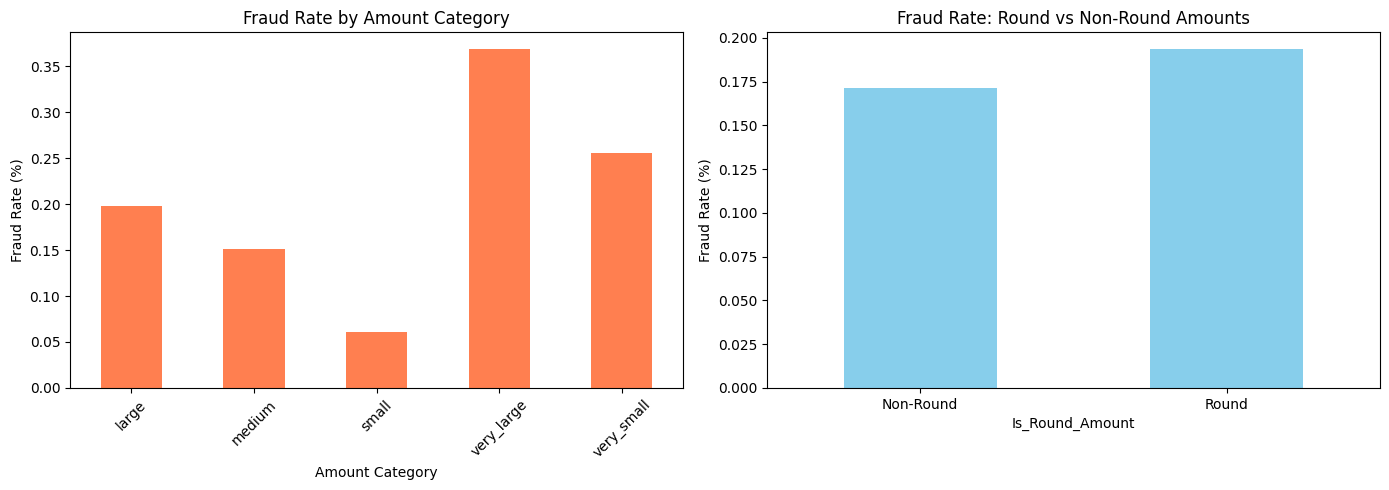

                 count  fraud_rate
Amount_Category                   
large            47893    0.198359
medium           37718    0.151121
small            92390    0.060613
very_large        9492    0.368732
very_small       97314    0.255873


In [5]:
# Cell 5: Analyze amount patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud rate by amount category
fraud_by_category = df.groupby('Amount_Category')['Class'].agg(['sum', 'count', 'mean'])
fraud_by_category['fraud_rate'] = fraud_by_category['mean'] * 100

fraud_by_category['fraud_rate'].plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Fraud Rate by Amount Category')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_xlabel('Amount Category')
axes[0].tick_params(axis='x', rotation=45)

# Round vs Non-round amounts
round_fraud_rate = df.groupby('Is_Round_Amount')['Class'].mean() * 100
round_fraud_rate.plot(kind='bar', ax=axes[1], color='skyblue')
axes[1].set_title('Fraud Rate: Round vs Non-Round Amounts')
axes[1].set_xticklabels(['Non-Round', 'Round'], rotation=0)
axes[1].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

print(fraud_by_category[['count', 'fraud_rate']])

In [6]:
# Cell 6: Create aggregate features from V1-V28

# Get all V columns
v_columns = [col for col in df.columns if col.startswith('V')]

# Create statistical features
df['V_sum'] = df[v_columns].sum(axis=1)
df['V_mean'] = df[v_columns].mean(axis=1)
df['V_std'] = df[v_columns].std(axis=1)
df['V_max'] = df[v_columns].max(axis=1)
df['V_min'] = df[v_columns].min(axis=1)

print("Statistical features created:")
print(df[['V_sum', 'V_mean', 'V_std', 'V_max', 'V_min']].head())

Statistical features created:
      V_sum    V_mean     V_std     V_max     V_min
0  3.081757  0.110063  0.744389  2.536347 -1.359807
1  4.439726  0.158562  0.488729  1.612727 -0.638672
2  1.091311  0.038975  1.169522  2.345865 -2.890083
3 -2.409596 -0.086057  0.819854  1.965775 -1.387024
4  5.378728  0.192097  0.657631  1.548718 -1.158233


Class distribution:
Legitimate (0): 284,315 (99.83%)
Fraud (1): 492 (0.17%)


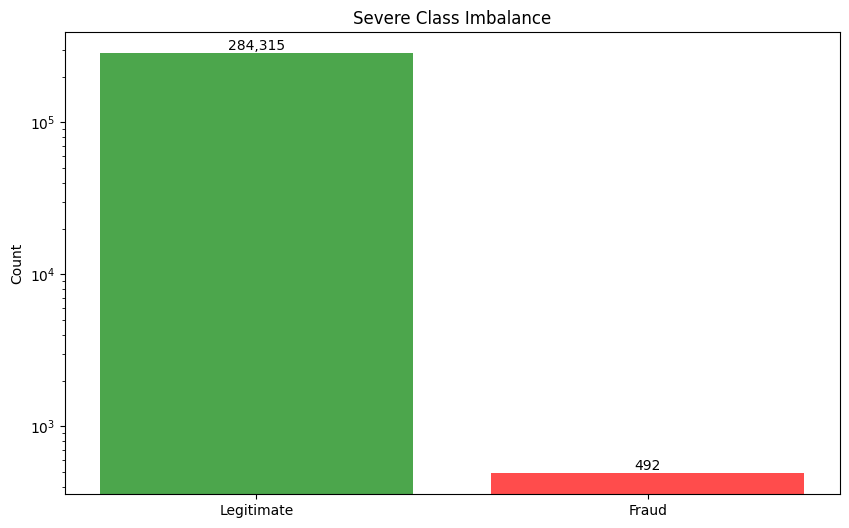

In [8]:
# Cell 7: Visualize the imbalance problem
class_counts = df['Class'].value_counts()
print(f"Class distribution:")
print(f"Legitimate (0): {class_counts[0]:,} ({class_counts[0]/len(df)*100:.2f}%)")
print(f"Fraud (1): {class_counts[1]:,} ({class_counts[1]/len(df)*100:.2f}%)")

plt.figure(figsize=(10, 6))
bars = plt.bar(['Legitimate', 'Fraud'], class_counts.values, color=['green', 'red'], alpha=0.7)
plt.ylabel('Count')
plt.title('Severe Class Imbalance')
plt.yscale('log')  # Log scale to see both bars

# Add count labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom')

plt.show()
# ```

# **The Problem:**
# - 284,315 legitimate transactions
# - Only 492 frauds
# - Ratio: ~577:1

# **What happens if we ignore this?**
# The model will learn: "Just predict everything as legitimate!" → 99.8% accuracy but 0% fraud detection!

# ### **Solution: SMOTE (Synthetic Minority Over-sampling Technique)**

# **What is SMOTE?**
# Imagine you have only 5 examples of fraud. SMOTE creates "synthetic" examples by:
# 1. Taking a fraud transaction
# 2. Finding its nearest neighbors (similar frauds)
# 3. Creating new examples "between" them

# **Visual concept:**
# ```
# Original Fraud Points:     After SMOTE:
#     X                         X  •
#                                  •  X
#     X                         X  •  •
#                                  •
# (5 frauds)                  (15 frauds - 5 original + 10 synthetic)

In [11]:
!pip install imbalanced-learn

In [12]:
# Cell 8: Install and import SMOTE
# Run this in terminal first: pip install imbalanced-learn

from imblearn.over_sampling import SMOTE
from collections import Counter

print("SMOTE library loaded successfully!")

SMOTE library loaded successfully!


In [13]:
# Cell 9: Prepare features and target

# Select features to use
feature_columns = (
    [col for col in df.columns if col.startswith('V')] +  # V1-V28
    ['Amount', 'Amount_Log', 'Hour', 'Day', 'Is_Night', 'Is_Round_Amount',
     'V_sum', 'V_mean', 'V_std', 'V_max', 'V_min']
)

print(f"Total features: {len(feature_columns)}")
print(f"Feature list: {feature_columns[:10]}...")  # Show first 10

# X = features, y = target
X = df[feature_columns]
y = df['Class']

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")

Total features: 44
Feature list: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10']...

X shape: (284807, 44)
y shape: (284807,)

Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [15]:
# Cell 10: Split data into training and testing sets
from sklearn.model_selection import train_test_split

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducibility
    stratify=y          # Keep same fraud ratio in both sets
)

print(f"Training set size: {len(X_train):,}")
print(f"Test set size: {len(X_test):,}")
print(f"\nTraining set fraud distribution:")
print(y_train.value_counts())
print(f"\nTest set fraud distribution:")
print(y_test.value_counts())


# **Why split?**
# ```
# All Data
#    ↓
#    ├─→ Training Set (80%) → Train model here
#    │
#    └─→ Test Set (20%) → Evaluate model here (model has never seen this!)

Training set size: 227,845
Test set size: 56,962

Training set fraud distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Test set fraud distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [16]:
# Cell 11: Scale features
from sklearn.preprocessing import StandardScaler

# Why scale? Different features have different ranges:
# Amount: $0 - $25,000
# Hour: 0 - 24
# V1: -56 to 2

# Scaling makes them comparable

scaler = StandardScaler()

# Fit scaler on training data only!
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before scaling - sample values:")
print(X_train.iloc[0])
print("\nAfter scaling - same sample:")
print(X_train_scaled[0])

Before scaling - sample values:
V1                  1.946747
V2                 -0.752526
V3                 -1.355130
V4                 -0.661630
V5                  1.502822
V6                  4.024933
V7                 -1.479661
V8                  1.139880
V9                  1.406819
V10                -0.157403
V11                -0.113729
V12                 0.510277
V13                 0.061258
V14                -0.066555
V15                 1.328702
V16                 0.352514
V17                -0.765670
V18                 0.141938
V19                -0.451365
V20                -0.134435
V21                 0.076197
V22                 0.297537
V23                 0.307915
V24                 0.690980
V25                -0.350316
V26                -0.388907
V27                 0.077641
V28                -0.032248
V_sum               7.156583
V_mean              0.255592
V_std               1.100494
V_max               4.024933
V_min              -1.479661
Amount     

Before SMOTE:
Training samples: 227,845
Counter({0: 227451, 1: 394})

After SMOTE:
Training samples: 454,902
Counter({0: 227451, 1: 227451})


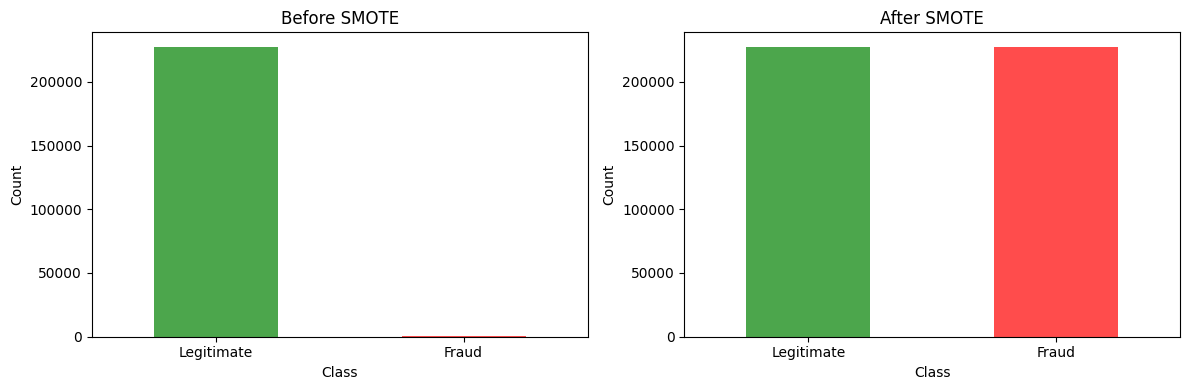

In [18]:
# Cell 12: Apply SMOTE to training data only

smote = SMOTE(random_state=42)

# Apply SMOTE
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:")
print(f"Training samples: {len(X_train_scaled):,}")
print(Counter(y_train))

print("\nAfter SMOTE:")
print(f"Training samples: {len(X_train_balanced):,}")
print(Counter(y_train_balanced))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before SMOTE
pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'], alpha=0.7)
axes[0].set_title('Before SMOTE')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
axes[0].set_ylabel('Count')

# After SMOTE
pd.Series(y_train_balanced).value_counts().plot(kind='bar', ax=axes[1], color=['green', 'red'], alpha=0.7)
axes[1].set_title('After SMOTE')
axes[1].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [19]:
# Cell 13: Train Logistic Regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Create model
log_model = LogisticRegression(
    max_iter=1000,      # Maximum iterations to find solution
    random_state=42,
    class_weight='balanced'  # Additional handling for imbalance
)

# Train the model
print("Training Logistic Regression model...")
log_model.fit(X_train_balanced, y_train_balanced)
print("✓ Model trained successfully!")

Training Logistic Regression model...
✓ Model trained successfully!


In [20]:
# Cell 14: Make predictions on test set

# Predict
y_pred = log_model.predict(X_test_scaled)

# Predict probabilities (how confident is the model?)
y_pred_proba = log_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions made!")
print(f"\nFirst 10 predictions: {y_pred[:10]}")
print(f"First 10 actual values: {y_test.values[:10]}")
print(f"\nFirst 10 probabilities: {y_pred_proba[:10]}")

Predictions made!

First 10 predictions: [0 0 0 0 1 0 0 0 0 0]
First 10 actual values: [0 0 0 0 0 0 0 0 0 0]

First 10 probabilities: [2.09697590e-03 8.70012451e-02 2.03593194e-07 9.09114607e-03
 9.41253135e-01 1.61428432e-02 1.08347411e-04 1.47343888e-02
 6.17072646e-02 2.72505633e-03]


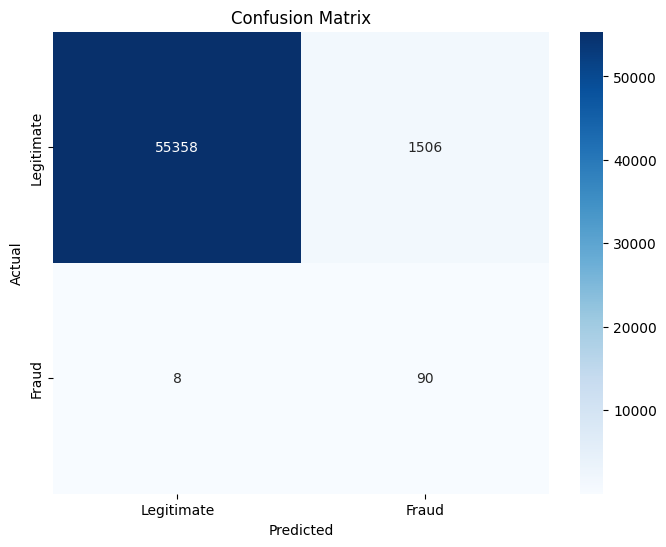

Confusion Matrix Breakdown:
True Negatives (TN): 55,358 - Correctly identified legitimate
False Positives (FP): 1,506 - Wrongly flagged as fraud
False Negatives (FN): 8 - Missed frauds (BAD!)
True Positives (TP): 90 - Correctly caught frauds (GOOD!)


In [23]:
# Cell 15: Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

print("Confusion Matrix Breakdown:")
print(f"True Negatives (TN): {cm[0,0]:,} - Correctly identified legitimate")
print(f"False Positives (FP): {cm[0,1]:,} - Wrongly flagged as fraud")
print(f"False Negatives (FN): {cm[1,0]:,} - Missed frauds (BAD!)")
print(f"True Positives (TP): {cm[1,1]:,} - Correctly caught frauds (GOOD!)")
# ```

# **Reading the Matrix:**
# ```
#                 Predicted
#               Legit  Fraud
# Actual Legit   TN     FP    ← False alarms
#        Fraud   FN     TP    ← Missed frauds
#               ↑      ↑
#          Correct  Caught!

In [24]:
# Cell 16: Detailed metrics
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

# Calculate additional metrics
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\n{'='*50}")
print(f"Key Metrics:")
print(f"{'='*50}")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"  → Of transactions we flagged, {precision*100:.1f}% were actually fraud")
print(f"\nRecall: {recall:.4f} ({recall*100:.2f}%)")
print(f"  → We caught {recall*100:.1f}% of all frauds")
print(f"\nF1-Score: {f1:.4f}")
print(f"  → Balance between precision and recall")
# ```

# **Understanding Metrics:**

# **Precision = TP / (TP + FP)**
# - High precision = Few false alarms
# - Important for customer experience (don't annoy customers)

# **Recall = TP / (TP + FN)**
# - High recall = Catch most frauds
# - Critical for banks (don't miss fraud!)

# **F1-Score**
# - Harmonic mean of precision and recall
# - Good when you need balance

# **For fraud detection:**
# ```
# Priority: RECALL > Precision
# Better to have false alarms than miss fraud!

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962


Key Metrics:
Precision: 0.0564 (5.64%)
  → Of transactions we flagged, 5.6% were actually fraud

Recall: 0.9184 (91.84%)
  → We caught 91.8% of all frauds

F1-Score: 0.1063
  → Balance between precision and recall


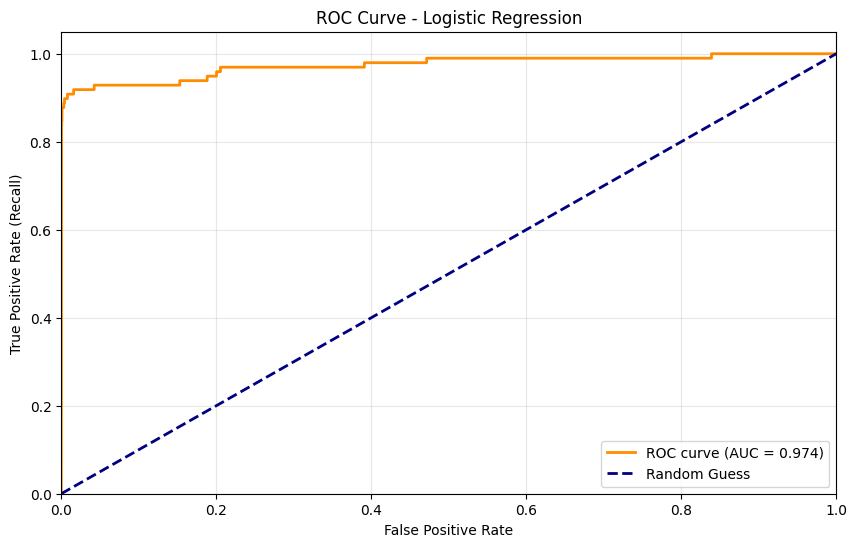

AUC Score: 0.9741


In [25]:
# Cell 17: ROC Curve
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

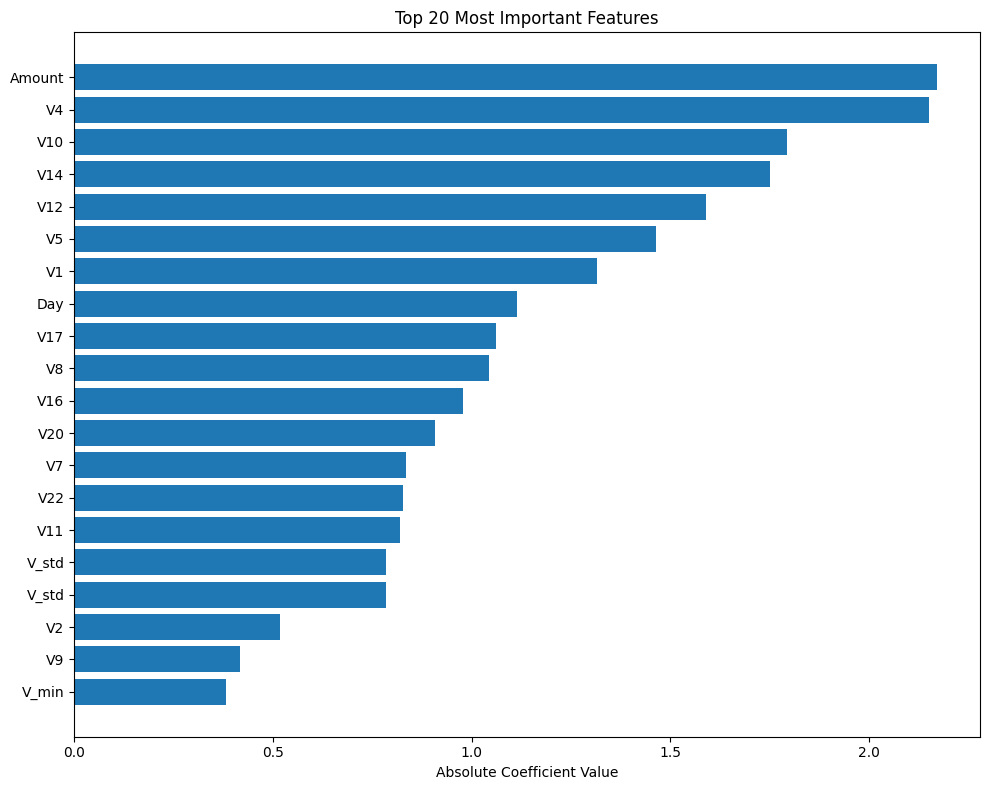

Top 10 Most Important Features:
   feature  importance
33  Amount    2.171314
3       V4    2.150495
9      V10    1.794336
13     V14    1.750653
11     V12    1.589193
4       V5    1.464144
0       V1    1.315421
36     Day    1.114689
16     V17    1.062519
7       V8    1.043634


In [26]:
# Cell 18: Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': np.abs(log_model.coef_[0])
}).sort_values('importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Absolute Coefficient Value')
plt.title('Top 20 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

In [27]:
# Cell 19: Install and train XGBoost
# Run in terminal: pip install xgboost

import xgboost as xgb

# Calculate scale_pos_weight for imbalance
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

print(f"Scale pos weight: {scale_pos_weight:.2f}")
print("This tells XGBoost to pay {:.0f}x more attention to fraud examples\n".format(scale_pos_weight))

# Create XGBoost model
xgb_model = xgb.XGBClassifier(
    max_depth=6,                    # How deep each tree can be
    learning_rate=0.1,              # How fast to learn
    n_estimators=100,               # Number of trees
    scale_pos_weight=scale_pos_weight,  # Handle imbalance
    random_state=42,
    eval_metric='aucpr'            # Use PR-AUC for imbalanced data
)

# Train
print("Training XGBoost model...")
xgb_model.fit(
    X_train_balanced, 
    y_train_balanced,
    verbose=False
)
print("✓ XGBoost model trained!")

Scale pos weight: 577.29
This tells XGBoost to pay 577x more attention to fraud examples

Training XGBoost model...
✓ XGBoost model trained!


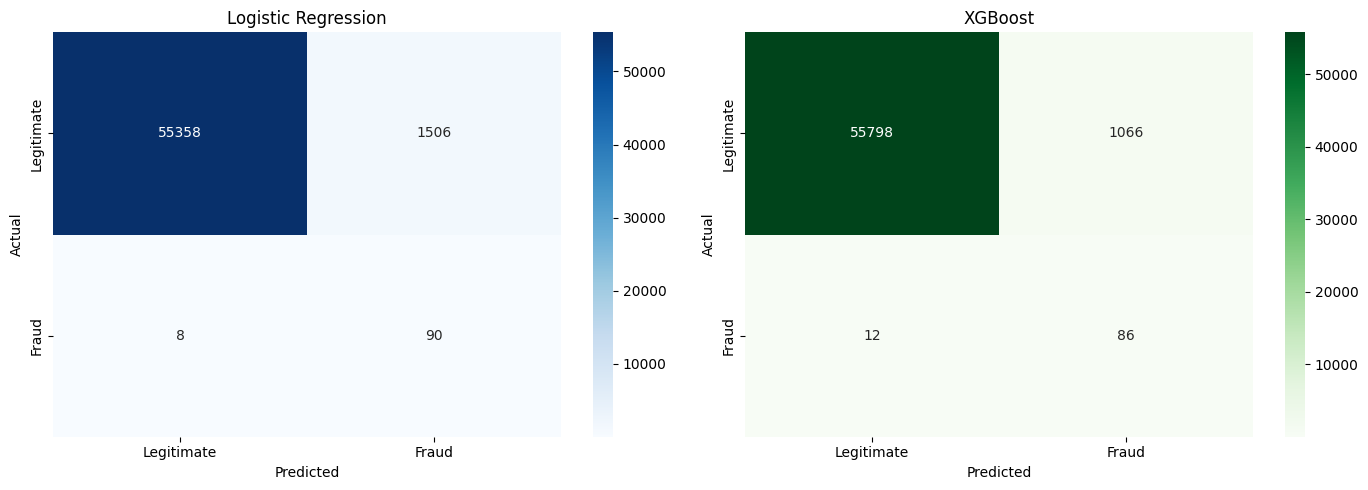

MODEL COMPARISON

Logistic Regression:
  Precision: 0.0564
  Recall:    0.9184
  F1-Score:  0.1063
  ROC-AUC:   0.9741

XGBoost:
  Precision: 0.0747
  Recall:    0.8776
  F1-Score:  0.1376
  ROC-AUC:   0.9686


In [28]:
# Cell 20: Evaluate XGBoost
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
axes[0].set_title('Logistic Regression')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# XGBoost
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
axes[1].set_title('XGBoost')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# Compare metrics
print("="*60)
print("MODEL COMPARISON")
print("="*60)

print("\nLogistic Regression:")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")

print("\nXGBoost:")
print(f"  Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")